<a href="https://colab.research.google.com/github/makxxic/NOTEBOOKS/blob/main/Stage7_LSTM_Imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This is the correct code but since my gpu has ended this is where i have correctly run it and produced an output
https://colab.research.google.com/drive/1t6lxyfS9747015opJ7MpU-GMJixu6pPt#scrollTo=qGx-qDWLuO57

##Step 1: Understanding the Assignment
Concept Explanation
What is Sentiment Analysis?

Sentiment Analysis is a Natural Language Processing (NLP) task where a machine learns to determine whether text expresses:

Positive sentiment (happy, satisfied, good review)

Negative sentiment (bad experience, criticism)

Example:

Movie Review	Sentiment
"This movie was fantastic!"	Positive
"I hated every minute of it."	Negative

We want a model that reads a review and predicts:

Positive → 1
Negative → 0

What is an LSTM?

An LSTM (Long Short-Term Memory) is a special type of Recurrent Neural Network (RNN) designed for sequence data, such as:

Text

Speech

Time-series data

Why LSTM works well for text:

Because word order matters.

Example:

"movie is good" ≠ "movie is not good"


LSTM remembers important words earlier in the sentence.

Example of how LSTM processes text

Sentence:

"The movie was not good"


Tokenized:

["the","movie","was","not","good"]


Converted to numbers:

[15, 201, 7, 82, 45]


The LSTM processes these one word at a time, remembering context.

Why This Matters

Understanding the problem and model ensures :

Choose correct preprocessing

Build the right architecture

Evaluate properly

##Step 2: Import Libraries

In [1]:
# Import PyTorch for deep learning
import torch
# Import neural network modules from PyTorch
import torch.nn as nn
# Import optimization algorithms
import torch.optim as optim
# Dataset and DataLoader utilities - Used for creating training batches.
from torch.utils.data import Dataset, DataLoader
# Import dataset loader from HuggingFace - Loads the IMDb dataset easily.
from datasets import load_dataset
# Used for text cleaning.
import re
# Used to build vocabulary.
from collections import Counter
# Numerical computation library
import numpy as np
# Used for working with tabular data.
import pandas as pd
# For better visualizations like confusion matrix.
import seaborn as sns
# Plotting library
import matplotlib.pyplot as plt
# Train validation split utility
from sklearn.model_selection import train_test_split
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

##Step 3: Load the IMDb Dataset
IMDb dataset contains:

50,000 movie reviews


Each review has:

text  → movie review
label → 0 (negative) or 1 (positive)


But for this assignment we only use:

first 10,000 samples


This makes training faster.

In [2]:
# Load IMDb dataset
dataset = load_dataset("imdb")
df_train = pd.DataFrame({"text": dataset["train"]["text"], "label": dataset["train"]["label"]})
df_test  = pd.DataFrame({"text": dataset["test"]["text"], "label": dataset["test"]["label"]})

sampled_train = df_train.sample(n=10000, random_state=42)
sampled_test  = df_test.sample(n=10000, random_state=42)

train_texts, train_labels = sampled_train["text"].tolist(), sampled_train["label"].tolist()
test_texts, test_labels   = sampled_test["text"].tolist(), sampled_test["label"].tolist()
# Displays dataset size.
print("Training samples:", len(train_texts))
print("Test samples:", len(test_texts))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples: 10000
Test samples: 10000


##Step 4: Text Cleaning
Models cannot learn from messy text.

Raw text contains:

HTML tags
punctuation
capital letters
extra spaces


Example:



Cleaned:

"this movie was amazing"


Cleaning improves model accuracy.

In [3]:

def clean_text(text):
    text = text.lower() # Converts to lowercase.
    text = re.sub(r"<.*?>", " ", text) # Removes HTML tags.
    text = re.sub(r"[^a-zA-Z ]", "", text) # Removes punctuation.
    return text
# Applies cleaning to all reviews.
train_texts = [clean_text(t) for t in train_texts]
test_texts = [clean_text(t) for t in test_texts]


##Step 5: Tokenization
Tokenization means splitting sentences into words.

In [4]:
def tokenize(text):
    return text.split() # Splits sentence by spaces.

train_tokens = [tokenize(t) for t in train_texts]
test_tokens = [tokenize(t) for t in test_texts]


##Step 6: Vocabulary Creation
Computers understand numbers, not words.

We convert each word into a unique integer index.

In [5]:
from collections import Counter

# Count word frequencies in training tokens
counter = Counter()
for tokens in train_tokens:
    counter.update(tokens)

# Define desired total vocabulary size INCLUDING special tokens
vocab_size = 20000

# Reserve 2 slots for special tokens (<PAD>, <UNK>)
# So we only take vocab_size - 2 actual words from the dataset
most_common = counter.most_common(vocab_size - 2)

# Build word-to-index dictionary
word2idx = {word: i+2 for i, (word, _) in enumerate(most_common)}

# Add special tokens manually
word2idx["<PAD>"] = 0   # padding
word2idx["<UNK>"] = 1   # unknown words

print("Vocabulary size (including PAD & UNK):", len(word2idx))

Vocabulary size (including PAD & UNK): 20000


##Step 7: Convert Text to Integer Sequences
Now convert tokens → numbers.

Each token is replaced by its corresponding index.

In [6]:
def encode(tokens):
    return [word2idx.get(word,1) for word in tokens]

train_encoded = [encode(t) for t in train_tokens]
test_encoded = [encode(t) for t in test_tokens]

##Step 8: Padding Sequences
Neural networks need same length input.

We pad shorter sequences with 0.

In [7]:
MAX_LEN = int(np.percentile([len(t) for t in train_tokens], 95))

def pad(seq):
    if len(seq) > MAX_LEN:
        return seq[:MAX_LEN]
    return seq + [0]*(MAX_LEN-len(seq))

train_padded = [pad(s) for s in train_encoded]
test_padded = [pad(s) for s in test_encoded]

##Step 9: Train Validation Split
We split the training data into:

80% training

20% validation

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
   train_padded, train_labels, test_size=0.15, random_state=42,stratify=train_labels
)

##Step 10: PyTorch Dataset Class
This class allows PyTorch to efficiently load training batches.

In [9]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts)
        self.labels = torch.tensor(labels).float()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

##Step 11: DataLoader
DataLoader helps load data in batches.

In [10]:
BATCH_SIZE = 64

train_loader = DataLoader(IMDBDataset(X_train,y_train),batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(IMDBDataset(X_val,y_val),batch_size=BATCH_SIZE)
test_loader = DataLoader(IMDBDataset(test_padded,test_labels),batch_size=BATCH_SIZE)

## Step 12: Download + Load GloVe

In [11]:
# Download GloVe automatically in Colab
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

def load_glove_embeddings(glove_path, word2idx, embed_dim):
    embeddings_index = {}
    with open(glove_path, encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = vector

    vocab_size = len(word2idx)
    embedding_matrix = np.zeros((vocab_size, embed_dim))
    for word, idx in word2idx.items():
        if word in embeddings_index:
            embedding_matrix[idx] = embeddings_index[word]
        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embed_dim,))
    return embedding_matrix


--2026-03-19 16:43:55--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-19 16:43:55--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-19 16:43:56--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

##Step 12: Build LSTM Model
We build an LSTM-based neural network using PyTorch. Model with Attention + Pretrained Embeddings

In [12]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        weights = torch.softmax(self.attn(lstm_out), dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        return context

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=200, hidden_dim=256,
                 n_layers=2, dropout=0.5, bidirectional=True,
                 pretrained_vectors=None, freeze=False):
        super().__init__()

        if pretrained_vectors is not None:
            embedding_matrix = torch.tensor(pretrained_vectors, dtype=torch.float)
            self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=bidirectional)

        self.attn = Attention(hidden_dim*2 if bidirectional else hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim*2 if bidirectional else hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        # The Attention module already returns the context vector, no need to re-apply softmax or sum
        context = self.attn(lstm_out)
        out = self.dropout(context)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out.squeeze(dim=-1)

##Step 13: Model Setup
Instantiate Model with Flexible GloVe

In [13]:
# Determine if a GPU is available and set the device accordingly for PyTorch operations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Initialize the SentimentLSTM model with the defined vocabulary size, embedding dimension (200), and hidden layer dimension (256)
# Move the model to the determined device (GPU if available, otherwise CPU)
embed_dim = 200   # choose 50, 100, 200, or 300
glove_path = f"glove.6B.{embed_dim}d.txt"
embedding_matrix = load_glove_embeddings(glove_path, word2idx, embed_dim)

model = SentimentLSTM(
    vocab_size=len(word2idx),
    embed_dim=embed_dim,
    hidden_dim=int(embed_dim*1.5),
    n_layers=2,
    dropout=0.5,
    bidirectional=True,
    pretrained_vectors=embedding_matrix,
    freeze=False
).to(device)
# Define the optimizer: Adam optimizer with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)
# Add Learning Rate Scheduler: ReduceLROnPlateau to decrease LR when validation loss stops improving
# factor controls how much the learning rate is reduced when the scheduler triggers.
# Example: if your LR = 0.001 and factor=0.5, the new LR becomes 0.0005.
# patience = number of epochs to wait without improvement before reducing the LR.
# verbose=True means the scheduler will print messages whenever it reduces the LR.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
# Define the loss function: Binary Cross Entropy Loss for binary classification
criterion = nn.BCEWithLogitsLoss()


##Step 14: Training Loop

In [14]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Validation label distribution:", np.unique(y_val, return_counts=True))
print("Test label distribution:", np.unique(test_labels, return_counts=True))


Train label distribution: (array([0, 1]), array([4282, 4218]))
Validation label distribution: (array([0, 1]), array([756, 744]))
Test label distribution: (array([0, 1]), array([5038, 4962]))


In [15]:
# --- Step 14: Training Loop (with early stopping and LR scheduling) ---
EPOCHS = 100
best_val_loss = float('inf') # Initialize best_val_loss to infinity for monitoring minimum loss
train_losses=[]
val_losses=[]
val_accs=[]
patience=2
patience_counter = 0 # Counter for patience

for epoch in range(EPOCHS):

    model.train()
    total_loss=0

    for x,y in train_loader:

        x,y = x.to(device),y.float().to(device)
        y = y.view(-1)
        optimizer.zero_grad()

        preds = model(x)

        loss = criterion(preds,y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss/len(train_loader))

    model.eval()

    val_loss=0
    preds_all=[]
    labels_all=[]

    with torch.no_grad():

        for x,y in val_loader:

            x,y = x.to(device),y.float().to(device)
            y = y.view(-1)
            preds=model(x)

            loss=criterion(preds,y)

            val_loss+=loss.item()
            preds = torch.sigmoid(preds)
            preds = (preds > 0.5).int()
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    current_val_loss = val_loss/len(val_loader) # Calculate average validation loss for the epoch
    val_losses.append(current_val_loss)

    acc = accuracy_score(labels_all,preds_all)

    val_accs.append(acc)

    print(f"Epoch {epoch+1} Train Loss: {train_losses[-1]:.4f}, Validation Accuracy: {acc:.4f}, Validation Loss: {current_val_loss:.4f},LR: {optimizer.param_groups[0]['lr']:.6f}") # Added validation loss to print

    # Step the learning rate scheduler with the current validation loss
    scheduler.step(current_val_loss)

    # Early stopping condition updated to monitor validation loss
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss # Update best_val_loss
        torch.save(model.state_dict(),"best_model.pth")
        print("Best model saved (based on validation loss).")
        patience_counter = 0 # Reset patience if validation loss improves
    else:
        patience_counter += 1 # Increment patience if validation loss does not improve

    if patience_counter >= patience:
        print(f"Early stopping triggered after {patience} epochs without improvement.")
        break # Break the training loop

Epoch 1 Train Loss: 0.6731, Validation Accuracy: 0.7060, Validation Loss: 0.6209,LR: 0.001000
Best model saved (based on validation loss).
Epoch 2 Train Loss: 0.4567, Validation Accuracy: 0.8553, Validation Loss: 0.3368,LR: 0.001000
Best model saved (based on validation loss).
Epoch 3 Train Loss: 0.2897, Validation Accuracy: 0.8413, Validation Loss: 0.3540,LR: 0.001000
Epoch 4 Train Loss: 0.1922, Validation Accuracy: 0.8760, Validation Loss: 0.3287,LR: 0.001000
Best model saved (based on validation loss).
Epoch 5 Train Loss: 0.1271, Validation Accuracy: 0.8793, Validation Loss: 0.3429,LR: 0.001000
Epoch 6 Train Loss: 0.0683, Validation Accuracy: 0.8807, Validation Loss: 0.4096,LR: 0.001000
Early stopping triggered after 2 epochs without improvement.


In [16]:
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: Tesla T4


##Step 17: Test Evaluation

In [17]:
# Load the best model weights obtained from training loop before testing
model.load_state_dict(torch.load("best_model.pth", weights_only=True))

model.eval()

preds_all=[]
labels_all=[]

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)
        y = y.to(device)

        preds=model(x)
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).int()
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

print("Accuracy:",accuracy_score(labels_all,preds_all))
print("Precision:",precision_score(labels_all,preds_all))
print("Recall:",recall_score(labels_all,preds_all))
print("F1:",f1_score(labels_all,preds_all))

Accuracy: 0.8638
Precision: 0.9149377593360996
Recall: 0.7998790810157195
F1: 0.8535483870967742


In [18]:
print(train_encoded[0][:20])
print(np.unique(y_train, return_counts=True))
print("Raw logits:", preds[:10])

[945, 7, 14, 945, 120, 8, 11, 1562, 2592, 414, 325, 207, 2021, 48, 510, 43, 14, 1359, 16527, 252]
(array([0, 1]), array([4282, 4218]))
Raw logits: tensor([1, 1, 0, 0, 1, 1, 0, 0, 1, 1], device='cuda:0', dtype=torch.int32)


In [19]:
x,y = next(iter(test_loader))

x = x.to(device)

with torch.no_grad():
    preds = model(x)

print("Raw logits:", preds[:10])

Raw logits: tensor([-6.9187, -1.4077, -5.8424,  3.7369, -0.2853, -2.1115, -6.1999, -0.7690,
         2.9112, -4.7596], device='cuda:0')


##Step 15: Training vs Validation Loss Plot

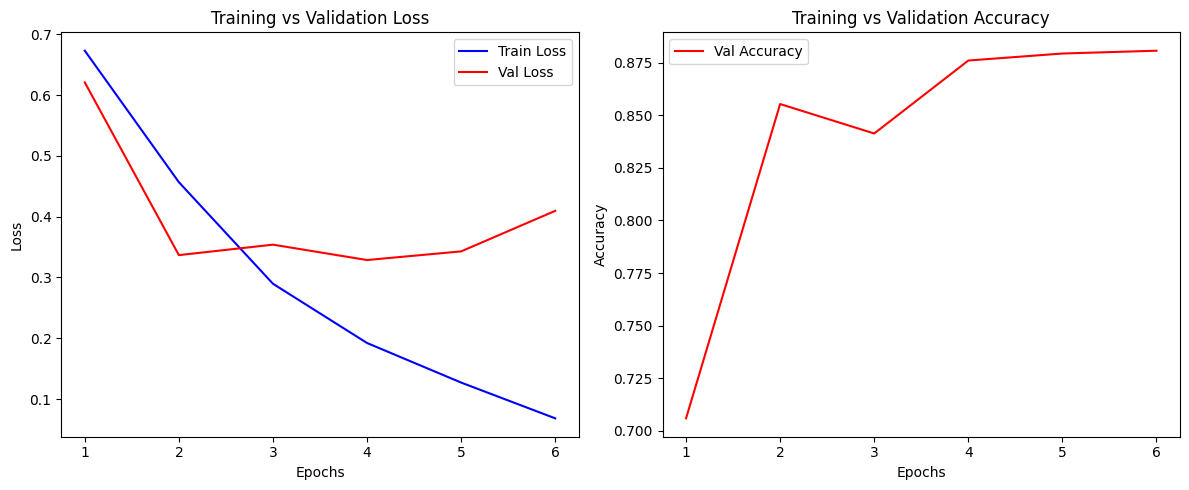

In [20]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

#  Loss subplot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

#  Accuracy subplot
plt.subplot(1,2,2)
plt.plot(epochs, val_accs, 'r-', label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

##Step 16: Confusion Matrix

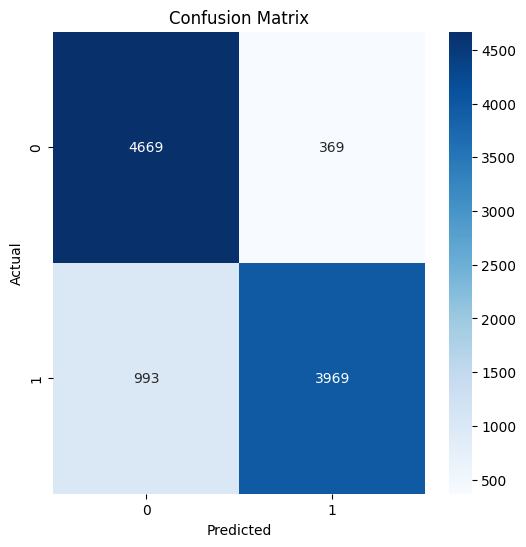

In [21]:
cm = confusion_matrix(labels_all, preds_all)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
